# Challenge 19 - Euler's Foward for Stiff Equations

Inference: Euler’s foward will fail here because the equation is stiff, so using a step size that is too large will likely make the solution unstable and causes the values to blow up instead of actually approximating the true solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<ipython-input-2-deef35e096cd>:8: RuntimeWarning: overflow encountered in double_scalars
  return (-1000*y)+3000-2000*np.exp(-t)
<ipython-input-2-deef35e096cd>:28: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])


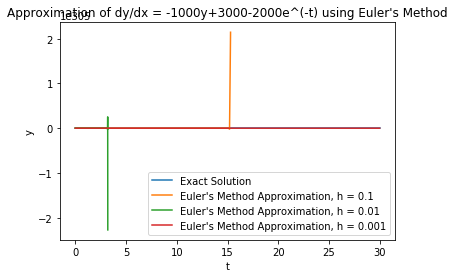

In [2]:
# Define parameters
t_start, t_end = 0, 30
hvals = [.1, .01, .001]  # step size
t_ex = np.linspace(t_start, t_end, 1000)

# Function representing dy/dx = -2y
def f(t, y):
    return (-1000*y)+3000-2000*np.exp(-t)
    
# Exact/ Analytical soln
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t) 

plt.plot(t_ex, y_exact(t_ex), label=f"Exact Solution")

 
for h in hvals:

    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 0  # y(0) = 0

   # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])
        
    # Plot the results
    plt.plot(t_values, y_values, label=f"Euler's Method Approximation, h = {h}")


plt.xlabel('t')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -1000y+3000-2000e^(-t) using Euler's Method")
plt.legend()
plt.show()

Conclusion: The code uses Euler’s Method to approximate the solution of a stiff differential equation. The graph shows that smaller step sizes h improve the accuracy and produce a smoother approximation, while larger step sizes lead to  errors, loss of stability, and they just blow up. Overall, the method is highly sensitive to step size due to the stiffness of the system. We need to use a new method to deal with these stiff equations, allowing us to use higher step sizes h to approximate the curves while keeping accuracy.